In [1]:
import pandas as pd
import numpy as np

In [2]:
# Please refer to BED file format
# https://en.wikipedia.org/wiki/BED_(file_format)

columns = ['chrom', 'chromStart', 'chromEnd', 'name']
h3k4me_df = pd.read_csv('dataset/HepG2_Male.histone.H3K4me3.peak.bed', sep="\t", header=None, names=columns)
h3k4me_df.head()

,chrom,chromStart,chromEnd,name
0,chr10,119808,119954,chr10_173
1,chr10,119956,120102,chr10_174
2,chr10,122100,122246,chr10_185
3,chr10,122308,122454,chr10_186
4,chr10,180346,180492,chr10_489


In [3]:
# Get distinct value of `chrom` column
h3k4me_df['chrom'].unique()

array(['chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16',
       'chr17', 'chr18', 'chr19', 'chr1', 'chr2', 'chr3', 'chrX', 'chr4',
       'chrY', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr20', 'chr21',
       'chr22'], dtype=object)

In [4]:
# Count the value of each chromosome type
h3k4me_df['chrom'].value_counts()

chrom
chr1     8597
chr2     6642
chr6     5378
chr17    5282
chr19    5256
chr3     4727
chr12    4321
chr11    4304
chr7     4135
chr5     3953
chr16    3946
chr9     3570
chr10    3569
chr4     3134
chr14    3009
chr8     2986
chr15    2766
chr20    2568
chr22    1991
chrX     1646
chr13    1629
chr18    1316
chr21     895
chrY       94
Name: count, dtype: int64

In [5]:
# Get the data of chr1 only
h3k4me_chr1_df = h3k4me_df.loc[h3k4me_df['chrom'] == 'chr1']
print(h3k4me_chr1_df.head())
print(h3k4me_chr1_df.shape)
print(h3k4me_chr1_df.describe())

      chrom  chromStart  chromEnd      name
35398  chr1      713385    713531  chr1_378
35399  chr1      713593    713739  chr1_379
35400  chr1      713828    713974  chr1_380
35401  chr1      714270    714416  chr1_381
35402  chr1      714393    714539  chr1_382
(8597, 4)
         chromStart      chromEnd
count  8.597000e+03  8.597000e+03
mean   1.064692e+08  1.064693e+08
std    7.759649e+07  7.759649e+07
min    7.133850e+05  7.135310e+05
25%    3.267130e+07  3.267145e+07
50%    9.539142e+07  9.539157e+07
75%    1.683128e+08  1.683129e+08
max    2.492012e+08  2.492014e+08


In [6]:
# Sort the data
h3k4me_chr1_df.sort_values(by='chromStart', ascending=True, inplace=True)
h3k4me_chr1_df.head()

C:\Users\abdul\AppData\Local\Temp\ipykernel_43524\2566274664.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  h3k4me_chr1_df.sort_values(by='chromStart', ascending=True, inplace=True)


,chrom,chromStart,chromEnd,name
35398,chr1,713385,713531,chr1_378
35399,chr1,713593,713739,chr1_379
35400,chr1,713828,713974,chr1_380
35401,chr1,714270,714416,chr1_381
35402,chr1,714393,714539,chr1_382


In [7]:
# Calculate the length of each chromosome by chromStart and chromEnd
h3k4me_chr1_df['length'] = h3k4me_chr1_df['chromEnd'] - h3k4me_chr1_df['chromStart']

C:\Users\abdul\AppData\Local\Temp\ipykernel_43524\2930988826.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  h3k4me_chr1_df['length'] = h3k4me_chr1_df['chromEnd'] - h3k4me_chr1_df['chromStart']


In [8]:
h3k4me_chr1_df.head()

,chrom,chromStart,chromEnd,name,length
35398,chr1,713385,713531,chr1_378,146
35399,chr1,713593,713739,chr1_379,146
35400,chr1,713828,713974,chr1_380,146
35401,chr1,714270,714416,chr1_381,146
35402,chr1,714393,714539,chr1_382,146


In [9]:
h3k4me_chr1_df.describe()

,chromStart,chromEnd,length
count,8.597000e+03,8.597000e+03,8597.0
mean,1.064692e+08,1.064693e+08,146.0
std,7.759649e+07,7.759649e+07,0.0
min,7.133850e+05,7.135310e+05,146.0
25%,3.267130e+07,3.267145e+07,146.0
50%,9.539142e+07,9.539157e+07,146.0
75%,1.683128e+08,1.683129e+08,146.0
max,2.492012e+08,2.492014e+08,146.0


In [10]:
# Bucketing
bin_size = 100000
result = (2.492012e+08 - 7.133850e+05)/bin_size
print(result)

2484.87815


In [11]:
# Create bucket of with size bin_range
bins = np.arange(7.0e+05, 2.5e+08, bin_size)
print(bins)

[7.000e+05 8.000e+05 9.000e+05 ... 2.497e+08 2.498e+08 2.499e+08]


In [12]:
h3k4me_chr1_df["bucket"] = pd.cut(h3k4me_chr1_df['chromStart'], bins)
h3k4me_chr1_df.head()

C:\Users\abdul\AppData\Local\Temp\ipykernel_43524\2054120170.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  h3k4me_chr1_df["bucket"] = pd.cut(h3k4me_chr1_df['chromStart'], bins)


,chrom,chromStart,chromEnd,name,length,bucket
35398,chr1,713385,713531,chr1_378,146,"(700000.0, 800000.0]"
35399,chr1,713593,713739,chr1_379,146,"(700000.0, 800000.0]"
35400,chr1,713828,713974,chr1_380,146,"(700000.0, 800000.0]"
35401,chr1,714270,714416,chr1_381,146,"(700000.0, 800000.0]"
35402,chr1,714393,714539,chr1_382,146,"(700000.0, 800000.0]"


In [13]:
np.histogram(h3k4me_chr1_df['chromStart'], bins)

(array([ 9, 10, 28, ...,  0,  0,  0], dtype=int64),
 array([7.000e+05, 8.000e+05, 9.000e+05, ..., 2.497e+08, 2.498e+08,
        2.499e+08]))

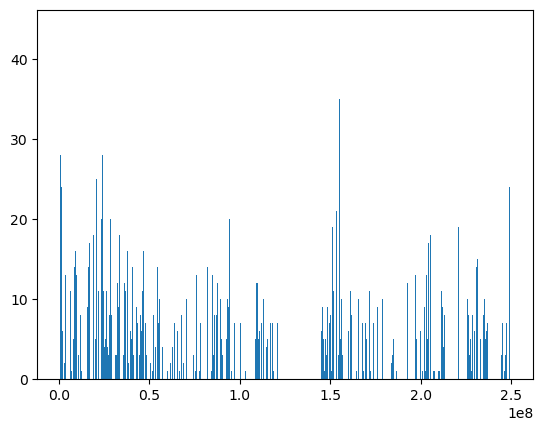

In [14]:
# Plot the distribution
from matplotlib import pyplot as plt

plt.hist(h3k4me_chr1_df['chromStart'], bins)
plt.show()

In [15]:
# With all data
h3k4me_df.describe()

,chromStart,chromEnd
count,8.571400e+04,8.571400e+04
mean,7.408782e+07,7.408797e+07
std,5.567607e+07,5.567607e+07
min,1.110300e+04,1.124900e+04
25%,3.132474e+07,3.132488e+07
50%,5.932348e+07,5.932363e+07
75%,1.097626e+08,1.097628e+08
max,2.492012e+08,2.492014e+08


In [16]:
# Bucketing
bin_size = 100000
bins = np.arange(0, 2.5e+08, bin_size)
print(bins)

[0.000e+00 1.000e+05 2.000e+05 ... 2.497e+08 2.498e+08 2.499e+08]


In [17]:
# Do the binning
h3k4me_df["bucket"] = pd.cut(h3k4me_df['chromStart'], bins)
h3k4me_df.head()

,chrom,chromStart,chromEnd,name,bucket
0,chr10,119808,119954,chr10_173,"(100000.0, 200000.0]"
1,chr10,119956,120102,chr10_174,"(100000.0, 200000.0]"
2,chr10,122100,122246,chr10_185,"(100000.0, 200000.0]"
3,chr10,122308,122454,chr10_186,"(100000.0, 200000.0]"
4,chr10,180346,180492,chr10_489,"(100000.0, 200000.0]"


In [18]:
np.histogram(h3k4me_df['chromStart'], bins)

(array([ 16,  55, 121, ...,   0,   0,   0], dtype=int64),
 array([0.000e+00, 1.000e+05, 2.000e+05, ..., 2.497e+08, 2.498e+08,
        2.499e+08]))

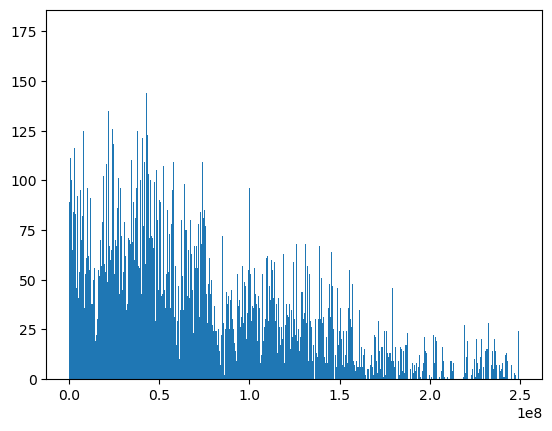

In [19]:
plt.hist(h3k4me_df['chromStart'], bins)
plt.show()

In [20]:
# Select data between 7016500 - 7019600

h3k4me_selected_df = h3k4me_df[(h3k4me_df['chromStart'] >= 7016500) & (h3k4me_df['chromStart'] <= 7019600)]
print(h3k4me_selected_df.head())
print(h3k4me_selected_df.shape)

       chrom  chromStart  chromEnd         name                  bucket
24047  chr17     7017186   7017332  chr17_35614  (7000000.0, 7100000.0]
24048  chr17     7017393   7017539  chr17_35615  (7000000.0, 7100000.0]
24049  chr17     7017640   7017786  chr17_35616  (7000000.0, 7100000.0]
24050  chr17     7017803   7017949  chr17_35617  (7000000.0, 7100000.0]
24051  chr17     7018178   7018324  chr17_35618  (7000000.0, 7100000.0]
(10, 5)


In [21]:
# Bucketing
bin_size = 200
bins = np.arange(7016500, 7019600, bin_size)
print(bins)

[7016500 7016700 7016900 7017100 7017300 7017500 7017700 7017900 7018100
 7018300 7018500 7018700 7018900 7019100 7019300 7019500]


In [22]:
# Do the binning
h3k4me_selected_df["bucket"] = pd.cut(h3k4me_selected_df['chromStart'], bins)
h3k4me_selected_df.head()

C:\Users\abdul\AppData\Local\Temp\ipykernel_43524\2071237371.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  h3k4me_selected_df["bucket"] = pd.cut(h3k4me_selected_df['chromStart'], bins)


,chrom,chromStart,chromEnd,name,bucket
24047,chr17,7017186,7017332,chr17_35614,"(7017100, 7017300]"
24048,chr17,7017393,7017539,chr17_35615,"(7017300, 7017500]"
24049,chr17,7017640,7017786,chr17_35616,"(7017500, 7017700]"
24050,chr17,7017803,7017949,chr17_35617,"(7017700, 7017900]"
24051,chr17,7018178,7018324,chr17_35618,"(7018100, 7018300]"


In [23]:
np.histogram(h3k4me_selected_df['chromStart'], bins)

(array([0, 0, 0, 1, 1, 2, 1, 0, 1, 1, 2, 1, 0, 0, 0], dtype=int64),
 array([7016500, 7016700, 7016900, 7017100, 7017300, 7017500, 7017700,
        7017900, 7018100, 7018300, 7018500, 7018700, 7018900, 7019100,
        7019300, 7019500]))

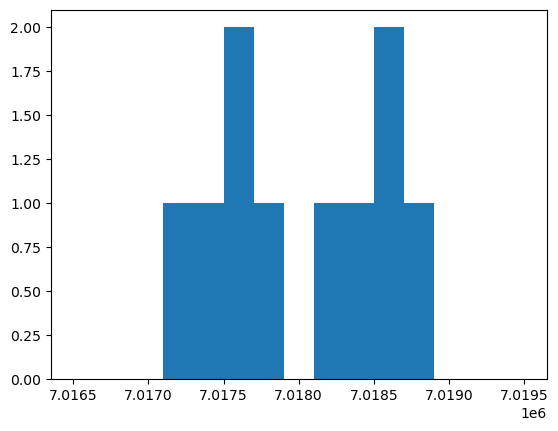

In [24]:
plt.hist(h3k4me_selected_df['chromStart'], bins)
plt.show()